# 03 — Eras, runway volume, and the FA-ist's pyramid

Two questions, both convention-dependent:

1. **How much has to exist at a grade before the next one appears?** For each
   breakthrough, count the routes already established at the outgoing top
   grade — the "runway" — under both conventions.
2. **What did the breakthrough climber's own record look like at that
   moment?** The FA-ist's pyramid, built from their *prior first ascents* in
   this dataset.

Two honest limits, stated up front. This dataset records **first ascents
only**, so the pyramids are FA pyramids — Ondra's repeats of other 9b's
before Change are invisible here, only his own FAs count. And the site is a
retrospective community record: routes climbed in the 1980s were entered
decades later, so early-era volumes reflect what the community remembered to
record (survivorship), not what a contemporary guidebook would have shown.

In [1]:
import numpy as np
import pandas as pd

from sportgradehistory import config
from sportgradehistory.grades import FRENCH_SCALE, french_ordinal
from sportgradehistory.milestones import breakthrough_table, load_sport

sport = load_sport()
BASE = french_ordinal("8a+")

tables = {c: breakthrough_table(sport, c) for c in ("as_proposed", "as_consensus")}

# The grade a route counts at, per convention.
grade_col = {"as_proposed": "proposed_order", "as_consensus": "grade_order"}

## The runway: routes at the top grade when the next one arrived

For breakthrough into grade *g+1* at date *t*: how many routes of grade *g*
(under the same convention) already had a first ascent before *t*? Year-only
FA dates are anchored to 1 January, so counts near a breakthrough can be off
by the handful of routes dated only to the breakthrough year — era edges are
soft by nature here.

In [2]:
rows = []
for convention, t in tables.items():
    col = grade_col[convention]
    for i in range(1, len(t)):
        target = t.iloc[i]
        prev_ordinal = t.iloc[i - 1]["grade_order"]
        runway = sport[
            (sport[col] == prev_ordinal)
            & sport["first_ascent"].notna()
            & (sport["first_ascent"] < target["first_ascent"])
        ]
        rows.append({
            "convention": convention,
            "into_grade": target["grade"],
            "breakthrough": target["first_ascent"].date(),
            "at_grade": FRENCH_SCALE[int(prev_ordinal)],
            "routes_on_runway": len(runway),
        })

era = pd.DataFrame(rows)
era.to_csv(config.PROCESSED_DIR / "era_runway_volumes.csv", index=False)
pivot = era.pivot_table(index="into_grade", columns="convention",
                        values="routes_on_runway", sort=False)
print(pivot.to_string())

convention  as_proposed  as_consensus
into_grade                           
8b                  1.0           1.0
8b+                 2.0           2.0
8c                  5.0           5.0
8c+                 5.0           5.0
9a                  2.0           1.0
9a+                17.0           7.0
9b                 10.0          18.0
9b+                10.0           8.0
9c                  3.0           3.0


Three regimes, not two. Through the Güllich years the runway was nearly
empty (one to five routes) — the pioneers outran the sport's ability to
consolidate. The middle grades waited for real volume: 9a+ arrived over a
17-route 9a runway (proposed reading), 9b over 10–18 at 9a+. Then the runway
*thins again at the top*: 9c arrived with only **three** 9b+'s standing —
at the extreme, the ceiling moves on the strength of one or two people, and
volume never accumulates before the next step. The conventions disagree most
exactly where the regrades cluster (8c+/9a/9a+/9b), because consensus moves
routes between runways retroactively.

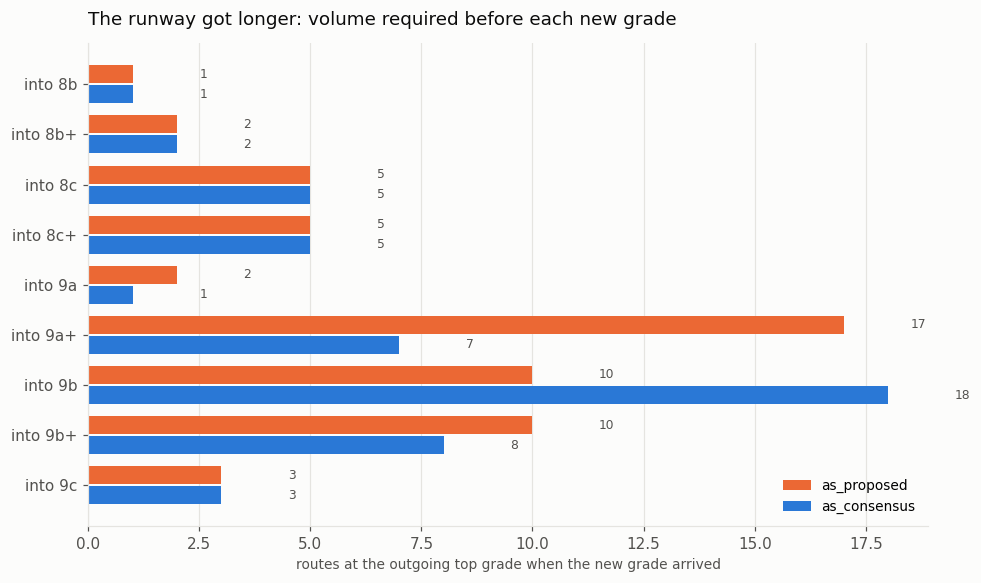

In [3]:
import matplotlib.pyplot as plt

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
BLUE, ORANGE = "#2a78d6", "#eb6834"

grades = pivot.index.tolist()
y = np.arange(len(grades))
fig, ax = plt.subplots(figsize=(9, 5.4), dpi=110, facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for offset, (conv, color) in zip((-0.2, 0.2),
                                 (("as_proposed", ORANGE), ("as_consensus", BLUE))):
    vals = pivot[conv].to_numpy()
    ax.barh(y + offset, vals, height=0.36, color=color, label=conv, zorder=2)
    for yi, v in zip(y + offset, vals):
        ax.text(v + 1.5, yi, f"{int(v)}", va="center", fontsize=8, color=MUTED)
ax.set_yticks(y); ax.set_yticklabels([f"into {g}" for g in grades], color=INK)
ax.invert_yaxis()
ax.set_xlabel("routes at the outgoing top grade when the new grade arrived",
              color=MUTED, fontsize=9)
ax.grid(axis="x", color=GRID, lw=.8, zorder=0)
for side in ("top", "right"): ax.spines[side].set_visible(False)
for side in ("left", "bottom"): ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.set_title("The runway got longer: volume required before each new grade",
             color=INK, fontsize=12, loc="left", pad=12)
plt.tight_layout(); plt.show()

## Routes established per era

An era runs from one consensus breakthrough to the next. How much hard
climbing (8a+ and up, consensus grades) was established during each?

In [4]:
t = tables["as_consensus"]
bounds = list(t["first_ascent"]) + [pd.Timestamp("2026-09-09")]
labels = [f"{a} era" for a in t["grade"]]
hard = sport[(sport["grade_order"] >= BASE) & sport["first_ascent"].notna()]

era_counts = pd.Series(
    pd.cut(hard["first_ascent"], bins=bounds, labels=labels, right=False)
).value_counts().reindex(labels, fill_value=0)
per_year = {
    lab: era_counts[lab] / max((b2 - b1).days / 365.25, 0.1)
    for lab, b1, b2 in zip(labels, bounds[:-1], bounds[1:])
}
out = pd.DataFrame({"routes_established": era_counts,
                    "per_year": pd.Series(per_year).round(1)})
print(out.to_string())

         routes_established  per_year
8a+ era                   1       1.0
8b era                    6       6.0
8b+ era                  23      11.5
8c era                   60      18.5
8c+ era                   1       4.8
9a era                   94      16.9
9a+ era                 267      21.0
9b era                  205      50.5
9b+ era                 204      41.5
9c era                  718      79.6


## The FA-ist's pyramid at the moment of breakthrough

For each `as_consensus` milestone: the climber's own prior first ascents in
this dataset, by consensus grade, strictly before the breakthrough date. A
`-` row means the site records no prior FA for them at all — for the early
Güllich milestones that is partly survivorship, partly the man simply moving
that fast.

In [5]:
t = tables["as_consensus"]
pyr_rows = []
for _, m in t.iterrows():
    prior = sport[
        (sport["first_climber"] == m["climber"])
        & sport["first_ascent"].notna()
        & (sport["first_ascent"] < m["first_ascent"])
        & (sport["grade_order"] >= french_ordinal("7c"))
    ]
    counts = prior["grade_clean"].value_counts()
    counts = counts.reindex(sorted(counts.index, key=french_ordinal))
    pyramid = "  ".join(f"{g}x{n}" for g, n in counts.items()) or "-"
    pyr_rows.append({"milestone": f"{m['grade']}  {m['route']}",
                     "year": m["first_ascent"].year,
                     "climber": m["climber"],
                     "prior_FAs_7c_and_up": pyramid})
pyr = pd.DataFrame(pyr_rows)
pyr.to_csv(config.PROCESSED_DIR / "milestone_fa_pyramids.csv", index=False)
print(pyr.to_string(index=False))

            milestone  year           climber                                                 prior_FAs_7c_and_up
        8a+  The Face  1983     Jerry Moffatt                                                         7c+x2  8ax1
  8b  Les Mains Sales  1984 Marc Le Menestrel                                                                8ax1
8b+  Punks in the Gym  1985  Wolfgang Güllich                                                   7c+x1  8ax1  8bx1
       8c  Wallstreet  1987  Wolfgang Güllich                                            7c+x1  8ax1  8bx4  8b+x1
    8c+  Liquid Ambar  1990     Jerry Moffatt                                     7c+x5  8ax4  8a+x2  8bx1  8b+x1
           9a  Hubble  1990          Ben Moon                                                    8ax2  8bx1  8cx2
             9a+  Qui  1996      Stefan Fürst                                                                   -
       9b  Jumbo Love  2008      Chris Sharma                               8bx2  8b+x1 

The modern pattern is unmistakable: Sharma reached Jumbo Love with a stack
of 8c+/9a/9a+ FAs behind him, Ondra reached Change and Silence with the
largest FA pyramid ever assembled. The early milestones ride on thin or empty
recorded pyramids — Güllich's Wallstreet and Action Directe show only a
handful of prior FAs here — which is the survivorship limit above doing its
work. Treat the pre-1995 pyramids as lower bounds, not biographies.

In [6]:
# Ondra at Silence, in full, as the extreme case.
m = t[t["route"] == "Silence"].iloc[0]
prior = sport[(sport["first_climber"] == m["climber"])
              & sport["first_ascent"].notna()
              & (sport["first_ascent"] < m["first_ascent"])
              & (sport["grade_order"] >= french_ordinal("8c"))]
print(f"Adam Ondra's recorded FAs of 8c+ and up before {m['first_ascent'].date()}: "
      f"{len(prior)}")
print(prior["grade_clean"].value_counts().reindex(
    sorted(set(prior['grade_clean']), key=french_ordinal)).to_string())

Adam Ondra's recorded FAs of 8c+ and up before 2017-09-03: 82
grade_clean
8c     12
8c+    17
9a     26
9a+    16
9b      8
9b+     3
